In [1]:
# STEP 1: Setup for SHAP analysis
print("="*80)
print("NOTEBOOK 04: SHAP EXPLAINABILITY ANALYSIS")
print("="*80)

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/sentiment_analysis_project'

NOTEBOOK 04: SHAP EXPLAINABILITY ANALYSIS
Mounted at /content/drive


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"\nSHAP version: {shap.__version__}")
print(f"Project path: {project_path}")


SHAP version: 0.50.0
Project path: /content/drive/MyDrive/sentiment_analysis_project


In [5]:
# STEP 2: Load models and data (UPDATED - LR only)
print("\n" + "="*80)
print("LOADING MODELS AND DATA")
print("="*80)

# Load saved models
lr_model = joblib.load(f'{project_path}/models/logistic_regression.pkl')
tfidf_vectorizer = joblib.load(f'{project_path}/models/tfidf_vectorizer.pkl')

print("Logistic Regression loaded")
print("TF-IDF vectorizer loaded")

# Load validation features and labels
X_val_tfidf = joblib.load(f'{project_path}/features/X_val_tfidf.pkl')
y_val = joblib.load(f'{project_path}/features/y_val.pkl')

print(f"Validation data loaded: {X_val_tfidf.shape}")

# Load validation text
df_full = pd.read_csv('/content/drive/MyDrive/sentiment_analysis_project/yelp_train_100k.csv')
df_full['text_length'] = df_full['text'].fillna('').astype(str).str.len()
df_full = df_full.sort_values('text_length').iloc[6063:].reset_index(drop=True)
df_full = df_full.drop('text_length', axis=1)

from sklearn.model_selection import train_test_split
_, X_val_text, _, y_val_text = train_test_split(
    df_full['text'],
    df_full['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_full['label']
)

print(f"Validation text loaded: {len(X_val_text)} samples")

# Select balanced sample for SHAP (50 negative + 50 positive)
np.random.seed(42)

neg_indices = np.where(y_val == 0)[0]
pos_indices = np.where(y_val == 1)[0]

sample_neg = np.random.choice(neg_indices, 50, replace=False)
sample_pos = np.random.choice(pos_indices, 50, replace=False)
sample_indices = np.concatenate([sample_neg, sample_pos])

X_sample_tfidf = X_val_tfidf[sample_indices]
y_sample = y_val.iloc[sample_indices]
X_sample_text = X_val_text.iloc[sample_indices]

print(f"\nSample created: {len(sample_indices)} reviews (50 negative + 50 positive)")
print(f"Sample class distribution:\n{y_sample.value_counts()}")


LOADING MODELS AND DATA
Logistic Regression loaded
TF-IDF vectorizer loaded
Validation data loaded: (18788, 5000)
Validation text loaded: 18788 samples

Sample created: 100 reviews (50 negative + 50 positive)
Sample class distribution:
label
0.0    50
1.0    50
Name: count, dtype: int64


In [6]:
# STEP 3: SHAP for Logistic Regression
print("\n" + "="*80)
print("SHAP ANALYSIS 1: LOGISTIC REGRESSION")
print("="*80)

# Create SHAP explainer for Logistic Regression
print("Creating SHAP explainer for Logistic Regression...")
lr_explainer = shap.LinearExplainer(lr_model, X_sample_tfidf, feature_perturbation="interventional")

# Calculate SHAP values
print("Calculating SHAP values (this takes ~2-3 minutes)...")
lr_shap_values = lr_explainer.shap_values(X_sample_tfidf)

print(f"SHAP values calculated")
print(f"Shape: {lr_shap_values.shape}")


SHAP ANALYSIS 1: LOGISTIC REGRESSION
Creating SHAP explainer for Logistic Regression...
Calculating SHAP values (this takes ~2-3 minutes)...
SHAP values calculated
Shape: (100, 5000)



Generating SHAP summary plot...


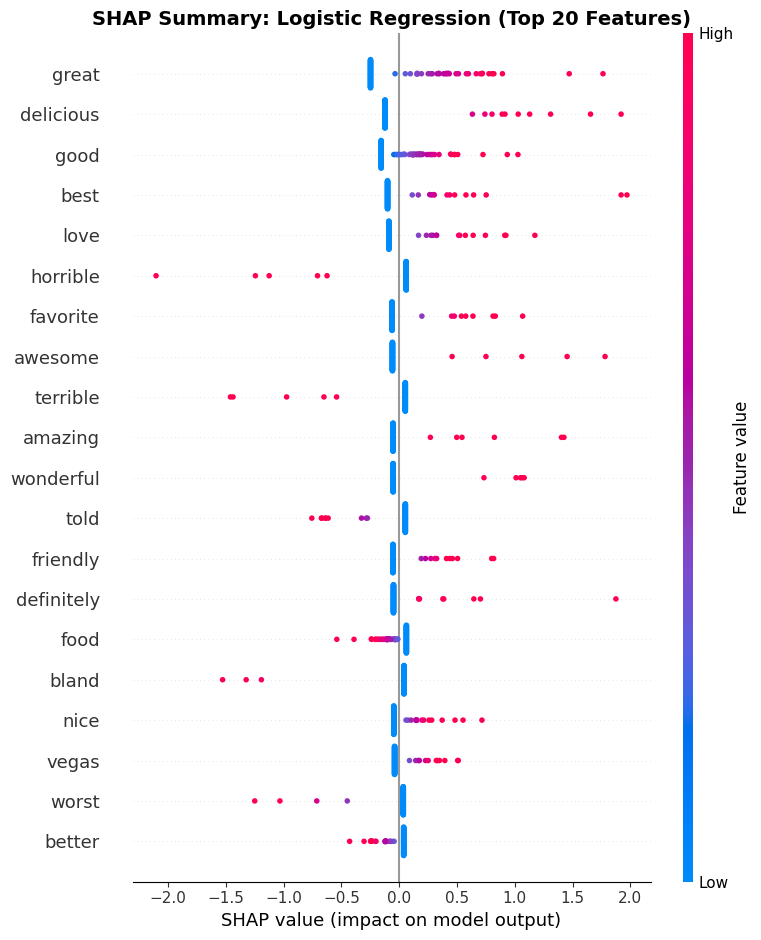


Plot saved: shap_lr_summary.png


In [7]:
# STEP 4: Create summary plot
print("\nGenerating SHAP summary plot...")

# Get feature names from TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Create summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    lr_shap_values,
    X_sample_tfidf.toarray(),  # Convert sparse to dense
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary: Logistic Regression (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{project_path}/shap_lr_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved: shap_lr_summary.png")

In [8]:
# Show feature importance (mean absolute SHAP values)
print("\n" + "="*80)
print("TOP 10 MOST IMPORTANT FEATURES (Logistic Regression)")
print("="*80)

# Calculate mean absolute SHAP value per feature
shap_importance = np.abs(lr_shap_values).mean(axis=0)

# Get top 10
top_indices = np.argsort(shap_importance)[-10:][::-1]
top_features = feature_names[top_indices]
top_importance = shap_importance[top_indices]

for feat, imp in zip(top_features, top_importance):
    print(f"{feat:30s}: {imp:.4f}")


TOP 10 MOST IMPORTANT FEATURES (Logistic Regression)
great                         : 0.3326
delicious                     : 0.2206
good                          : 0.1892
best                          : 0.1725
love                          : 0.1525
horrible                      : 0.1160
favorite                      : 0.1119
awesome                       : 0.1101
terrible                      : 0.1012
amazing                       : 0.0993
